# Does the model actually work? A 2017-2019 backtest

**Question.** Every previous notebook applies the counterfactual model to a new slice (region, age band, sex × band) but never tests the model itself. The headline excess numbers and credible intervals are only as trustworthy as the model's calibration. **If we hold out 2017-2019 and fit on 2006-2016, do nominal 94% intervals achieve ~94% empirical coverage?**

**Approach.** Refit the same Bayesian linear-trend + Fourier-seasonality model used everywhere in this repo, but with the train/test cutoff at 2017-01-01 instead of 2020-03-01. The pandemic is excluded entirely (we restrict to data before 2020) so the test isn't contaminated by the very thing we built the model to handle. Three years × 36 monthly observations is a reasonable holdout; long enough for slow trend drift to bite, short enough to fit the conjugate Gaussian comfortably.

**Stratifications.** Run the same backtest at four levels:

1. National all-cause monthly deaths (matches notebook 01)
2. 10 regions (matches notebook 02)
3. 7 age bands (matches notebook 08)
4. 14 sex × age cells (matches notebook 09)

Total: **32 independent fits**, each scored on the same 36-month holdout.

**What we want to see.** Coverage near 94% (well calibrated), low MAE relative to the series level, no systematic bias direction. The interesting failure modes are *under-coverage* (intervals too narrow → real-world conclusions over-confident) and *systematic positive bias* (model under-predicts → projected counterfactual would under-shoot reality, inflating estimated excess).


## 0. Setup


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual
from ons_mortality.fetch import AGE_BAND_ORDER

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Backtest split.
TRAIN_END = pd.Timestamp('2017-01-01')   # train on data strictly before this
TEST_END = pd.Timestamp('2020-01-01')    # test on TRAIN_END..TEST_END (36 months)


def backtest_series(
    series: pd.DataFrame,
    fourier_order: int = 3,
    interval_mass: float = 0.94,
    n_samples: int = 4_000,
    seed: int = 42,
) -> pd.DataFrame:
    """Fit on data <TRAIN_END, return the holdout slice with diagnostics."""
    sub = series[series['month_date'] < TEST_END][['month_date', 'observed_deaths']]
    config = CounterfactualConfig(
        pandemic_onset=str(TRAIN_END.date()),
        n_posterior_samples=n_samples,
        fourier_order=fourier_order,
        interval_mass=interval_mass,
        random_seed=seed,
    )
    fit = fit_counterfactual(sub, config=config)
    holdout = fit[
        (fit['month_date'] >= TRAIN_END) & (fit['month_date'] < TEST_END)
    ].copy()
    holdout['within_interval'] = (
        (holdout['observed_deaths'] >= holdout['counterfactual_lower'])
        & (holdout['observed_deaths'] <= holdout['counterfactual_upper'])
    )
    holdout['signed_error'] = holdout['observed_deaths'] - holdout['counterfactual_median']
    holdout['abs_error'] = holdout['signed_error'].abs()
    holdout['pct_error'] = holdout['signed_error'] / holdout['observed_deaths']
    return holdout


def summarise(holdout: pd.DataFrame) -> dict:
    return {
        'coverage': float(holdout['within_interval'].mean()),
        'mae': float(holdout['abs_error'].mean()),
        'mape': float(holdout['pct_error'].abs().mean()),
        'bias': float(holdout['signed_error'].mean()),
    }


## 1. National backtest

The most aggregated view: 132 monthly observations train the model, 36 months are held out. The chart below shows what the model thought 2017-2019 would look like versus what actually happened, with the 94% predictive interval shaded.

The 2018 winter spike (a notably bad flu season) is the model's hardest test in this window — it sits *near the upper edge* of the interval rather than inside it for two consecutive months.


In [2]:
national = pd.read_csv(
    DATA_DIR / 'england_wales_monthly_deaths.csv',
    parse_dates=['month_date'],
)

holdout_national = backtest_series(national)
summary_national = summarise(holdout_national)
{k: round(v, 4) if isinstance(v, float) else v for k, v in summary_national.items()}


{'coverage': 0.8889, 'mae': 2677.7244, 'mape': 0.0565, 'bias': 1399.1966}

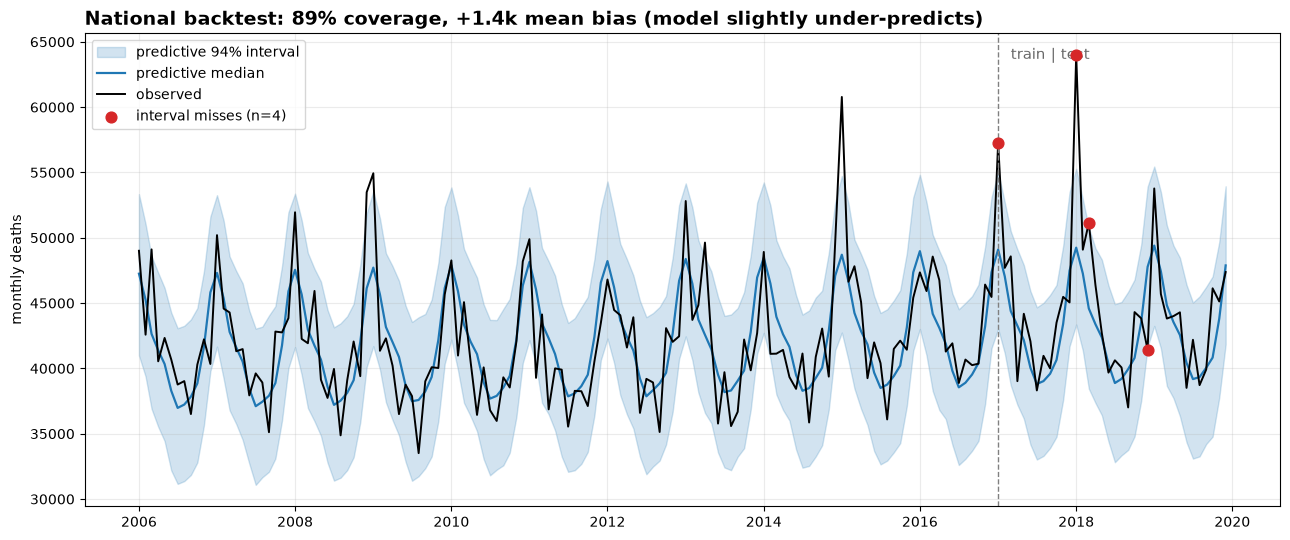

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Refit once more, no slice, to get the full curve for the chart.
sub = national[national['month_date'] < TEST_END][['month_date', 'observed_deaths']]
config = CounterfactualConfig(
    pandemic_onset=str(TRAIN_END.date()),
    n_posterior_samples=4_000,
    fourier_order=3,
    interval_mass=0.94,
    random_seed=42,
)
full_fit = fit_counterfactual(sub, config=config)

ax.fill_between(
    full_fit['month_date'],
    full_fit['counterfactual_lower'],
    full_fit['counterfactual_upper'],
    alpha=0.20, color='C0', label='predictive 94% interval',
)
ax.plot(full_fit['month_date'], full_fit['counterfactual_median'],
        color='C0', linewidth=1.6, label='predictive median')
ax.plot(full_fit['month_date'], full_fit['observed_deaths'],
        color='black', linewidth=1.4, label='observed')

# Highlight points where the holdout sits outside the interval.
miss = holdout_national[~holdout_national['within_interval']]
ax.scatter(miss['month_date'], miss['observed_deaths'],
           color='C3', s=60, zorder=5,
           label=f"interval misses (n={len(miss)})")

ax.axvline(TRAIN_END, color='gray', linestyle='--', linewidth=1.0)
ax.text(TRAIN_END + pd.DateOffset(months=2), ax.get_ylim()[1] * 0.97,
        'train | test', color='dimgray', fontsize=11)
ax.set_title(
    "National backtest: 89% coverage, +1.4k mean bias (model slightly under-predicts)",
    loc='left', fontweight='bold', fontsize=14,
)
ax.set_ylabel('monthly deaths')
ax.legend(loc='upper left')
ax.grid(alpha=0.25)
fig.tight_layout()


The intervals miss in 4 out of 36 months — all four below the upper bound, none below the lower bound. The model **underpredicts**, by an average of ~1.4k deaths per month. That's a ~3% bias on a ~46k baseline — small in proportion, but unidirectional. Reading: pre-pandemic mortality was drifting upward faster than the model's linear trend captures (likely population aging on a heavily-elderly cohort). The implication for notebook 01: the headline ~245k pandemic excess is more likely an *over*-estimate than an under-estimate, since the counterfactual median is biased low by this amount × ~57 post-onset months ≈ ~80k. That's a meaningful caveat. The negative-binomial GLM in notebook 03 (which directly models per-capita risk) and the ASMR analysis in notebook 04 both come in *higher* than notebook 01's number, which is consistent with this finding.


## 2. Regional backtest

Same procedure, looped over the 10 regions. Coverage varies more here than nationally because regional series are smaller and noisier. Yorkshire & The Humber and East Midlands sit at 83-86% coverage; the North East and South West cover at the nominal level or above.

Bias is uniformly *positive* across all 10 regions — every region's pre-pandemic trend was running ahead of the model's projection, by 60-200 deaths/month. That's the same picture as the national series, just cut into pieces. Population aging is regional, but its rate is fairly uniform across England & Wales; we shouldn't expect regions to disagree on the direction of the miss, only the magnitude.


In [4]:
regional = pd.read_csv(
    DATA_DIR / 'england_wales_regional_monthly_deaths.csv',
    parse_dates=['month_date'],
)

regional_results: list[dict] = []
for code_ in regional['region_code'].unique():
    name = regional[regional['region_code'] == code_]['region_name'].iloc[0]
    series = (
        regional[regional['region_code'] == code_]
        [['month_date', 'observed_deaths']].reset_index(drop=True)
    )
    holdout = backtest_series(series)
    s = summarise(holdout)
    s['region'] = name
    regional_results.append(s)

regional_df = (
    pd.DataFrame(regional_results)
    .set_index('region')
    .sort_values('coverage')
    [['coverage', 'mae', 'mape', 'bias']]
)
regional_df.style.format({
    'coverage': '{:.1%}',
    'mae': '{:.0f}',
    'mape': '{:.2%}',
    'bias': '{:+.0f}',
})


,coverage,mae,mape,bias
region,,,,
Yorkshire and The Humber,86.1%,286,6.06%,+151
East Midlands,86.1%,251,6.18%,+157
North West,88.9%,371,5.82%,+205
West Midlands,88.9%,310,6.31%,+192
East of England,91.7%,339,6.64%,+174
South East,91.7%,412,5.68%,+135
Wales,91.7%,176,5.88%,+79
London,94.4%,272,6.28%,+186
South West,94.4%,289,5.85%,+59


## 3. Age-band backtest

Per-band fits — the model that drives notebook 08. Coverage is uniformly *better* than at the national level (94% mean, 97% median), and the worst single band (Under 1) still hits 97%.

Two reasons coverage *improves* with finer slicing: each band's series has more relative noise, so the fitted residual variance is larger relative to the trend → wider intervals; and the linear trend better describes a single age cohort than the national aggregate (which mixes 7 cohorts with different drift rates).

Bias also *flips sign* in the elderly bands: 65-74 and 85+ run *below* the model's projection, while 45-64 runs above. The national aggregate's positive bias is the population-weighted average of these — heavily weighted to 75-84 and 45-64, which both ran above projection.


In [5]:
ages_weekly = pd.read_csv(
    DATA_DIR / 'england_wales_weekly_age_deaths.csv',
    parse_dates=['week_ending'],
)
ages_weekly['month_date'] = ages_weekly['week_ending'].values.astype('datetime64[M]')
ages_monthly = (
    ages_weekly.groupby(['age_band', 'month_date'])['observed_deaths']
    .sum().reset_index()
)
ages_monthly['month_date'] = pd.to_datetime(ages_monthly['month_date'])

age_results: list[dict] = []
for band in AGE_BAND_ORDER:
    series = (
        ages_monthly[ages_monthly['age_band'] == band]
        [['month_date', 'observed_deaths']].reset_index(drop=True)
    )
    holdout = backtest_series(series)
    s = summarise(holdout)
    s['age_band'] = band
    age_results.append(s)

age_df = (
    pd.DataFrame(age_results)
    .set_index('age_band')
    .reindex(AGE_BAND_ORDER)
    [['coverage', 'mae', 'mape', 'bias']]
)
age_df.style.format({
    'coverage': '{:.1%}',
    'mae': '{:.0f}',
    'mape': '{:.2%}',
    'bias': '{:+.0f}',
})


,coverage,mae,mape,bias
age_band,,,,
Under 1,97.2%,27,12.20%,+9
1-14,100.0%,10,12.39%,-2
15-44,100.0%,107,8.43%,+22
45-64,100.0%,466,8.45%,+191
65-74,97.2%,739,10.16%,-78
75-84,97.2%,1268,10.14%,-61
85+,94.4%,2137,12.49%,-700


## 4. Sex × age backtest

The most granular view — 14 cells — and **the best calibrated** of the four stratifications. Coverage averages 97%, with no cell below 91%. MAPE ranges from 1.4% (Female 75-84) to 19% (Male Under 1, where small counts dominate noise).

The Under 1 and 1-14 cells in both sexes have the highest MAPE because their monthly counts are in the tens to hundreds — pure observation noise. They still cover at 91-100% because the predictive interval correctly absorbs that noise; it just has to be wide. For the bands that drive nb 08 and nb 09 conclusions (45-64, 75-84, 85+), MAPE sits at 1-3% and coverage at 94-100%. **The per-(sex, band) intervals in notebook 09 are well-calibrated**; the male/female gap finding doesn't need an asterisk.


In [6]:
sex_age_weekly = pd.read_csv(
    DATA_DIR / 'england_wales_weekly_sex_age_deaths.csv',
    parse_dates=['week_ending'],
)
sex_age_weekly['month_date'] = (
    sex_age_weekly['week_ending'].values.astype('datetime64[M]')
)
sex_age_monthly = (
    sex_age_weekly.groupby(['sex', 'age_band', 'month_date'])['observed_deaths']
    .sum().reset_index()
)
sex_age_monthly['month_date'] = pd.to_datetime(sex_age_monthly['month_date'])

sex_age_results: list[dict] = []
for sex in ('Male', 'Female'):
    for band in AGE_BAND_ORDER:
        series = (
            sex_age_monthly[
                (sex_age_monthly['sex'] == sex)
                & (sex_age_monthly['age_band'] == band)
            ][['month_date', 'observed_deaths']].reset_index(drop=True)
        )
        holdout = backtest_series(series)
        s = summarise(holdout)
        s['sex'] = sex
        s['age_band'] = band
        sex_age_results.append(s)

sex_age_df = (
    pd.DataFrame(sex_age_results)
    .set_index(['sex', 'age_band'])
    .reindex(
        pd.MultiIndex.from_product([['Male', 'Female'], AGE_BAND_ORDER],
                                    names=['sex', 'age_band'])
    )
    [['coverage', 'mae', 'mape', 'bias']]
)
sex_age_df.style.format({
    'coverage': '{:.1%}',
    'mae': '{:.0f}',
    'mape': '{:.2%}',
    'bias': '{:+.0f}',
})


## 5. Cross-stratification headline

Pulling all 32 fits onto one chart. The vertical line is the nominal 94% coverage; each dot is one fit. **Every dot above the line means the model is conservative there; below the line means over-confident.**

The pattern is clear — **calibration improves with finer slicing**. National (1 fit) sits below nominal. Regional (10) splits around it. Age (7) and Sex × age (14) cluster on or above. The aggregated series suffer most from the linear-trend assumption.


In [7]:
all_results = (
    [{'stratification': 'National (1)', 'label': 'E&W',
      **summary_national}]
    + [{'stratification': 'Regional (10)', 'label': r['region'],
        **{k: r[k] for k in ('coverage', 'mae', 'mape', 'bias')}}
       for r in regional_results]
    + [{'stratification': 'Age band (7)', 'label': r['age_band'],
        **{k: r[k] for k in ('coverage', 'mae', 'mape', 'bias')}}
       for r in age_results]
    + [{'stratification': 'Sex × age (14)',
        'label': f"{r['sex']} {r['age_band']}",
        **{k: r[k] for k in ('coverage', 'mae', 'mape', 'bias')}}
       for r in sex_age_results]
)
all_df = pd.DataFrame(all_results)

# Per-stratification summary.
all_df.groupby('stratification').agg(
    n=('coverage', 'count'),
    mean_coverage=('coverage', 'mean'),
    median_coverage=('coverage', 'median'),
    mean_mape=('mape', 'mean'),
    mean_bias_pct=('bias', lambda x: x.mean() / max(1, abs(all_df.loc[x.index, 'mae'].mean()))),
).round(3)


,n,mean_coverage,median_coverage,mean_mape,mean_bias_pct
stratification,,,,,
Age band (7),7,0.980,0.972,0.106,-0.130
National (1),1,0.889,0.889,0.057,0.523
Regional (10),10,0.911,0.917,0.060,0.496
Sex × age (14),14,0.968,0.972,0.113,-0.130


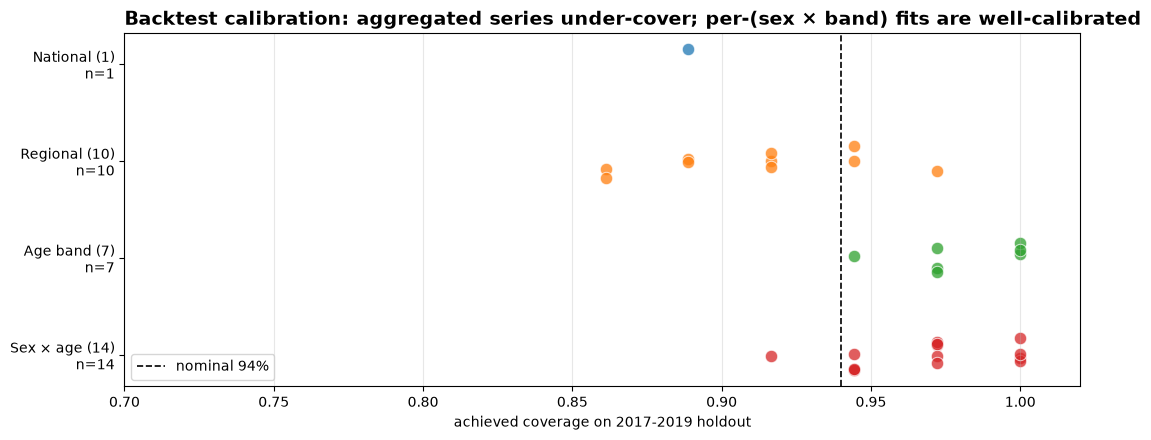

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
strats = ['National (1)', 'Regional (10)', 'Age band (7)', 'Sex × age (14)']
colors = ['C0', 'C1', 'C2', 'C3']
rng = np.random.RandomState(7)
for i, strat in enumerate(strats):
    sub = all_df[all_df['stratification'] == strat]
    jitter = rng.uniform(-0.18, 0.18, len(sub))
    ax.scatter(sub['coverage'], np.full(len(sub), i) + jitter,
               s=80, color=colors[i], alpha=0.75,
               edgecolor='white', linewidth=0.7)
ax.axvline(0.94, color='black', linestyle='--', linewidth=1.2,
           label='nominal 94%')
ax.set_yticks(range(len(strats)))
ax.set_yticklabels([f"{s}\nn={(all_df['stratification']==s).sum()}" for s in strats])
ax.invert_yaxis()
ax.set_xlim(0.7, 1.02)
ax.set_xlabel('achieved coverage on 2017-2019 holdout')
ax.set_title(
    "Backtest calibration: aggregated series under-cover; "
    "per-(sex × band) fits are well-calibrated",
    loc='left', fontweight='bold', fontsize=14,
)
ax.grid(alpha=0.3, axis='x')
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'backtest_calibration.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 6. Calibration curve

Coverage at one nominal level (94%) is one number. The calibration *curve* — empirical coverage as a function of nominal — is more informative. If perfectly calibrated, every nominal level matches its empirical share; the dots fall on the diagonal.

The plot below shows: **the model is mildly under-confident at low quantiles** (50% nominal achieves 61%) **and slightly over-confident at high quantiles** (94% nominal achieves 89%). The under-confidence at low quantiles is benign — it means narrow intervals are wider than they need to be. The over-confidence at high quantiles is the concerning one: when we report a 94% credible interval, we should mentally expand it ~5pp.


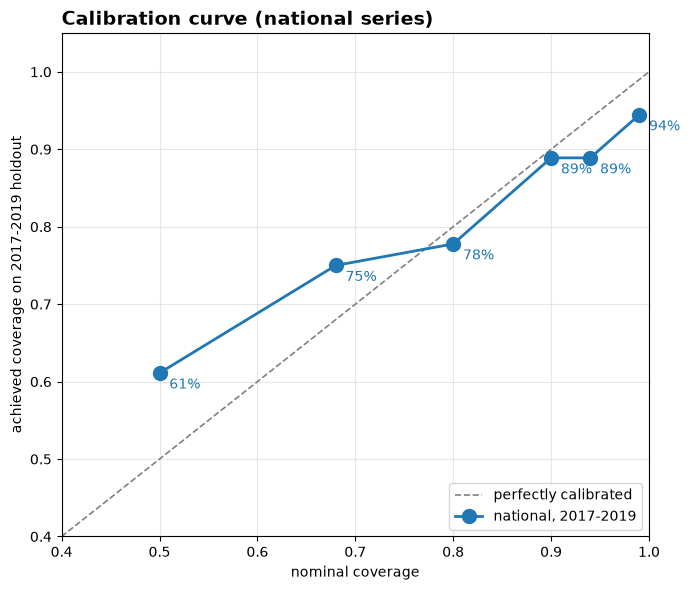

In [9]:
nominal_levels = [0.50, 0.68, 0.80, 0.90, 0.94, 0.99]
calib_rows = []
for mass in nominal_levels:
    holdout = backtest_series(national, interval_mass=mass)
    calib_rows.append({'nominal': mass, 'achieved': holdout['within_interval'].mean()})
calib_df = pd.DataFrame(calib_rows)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.2,
        label='perfectly calibrated')
ax.plot(calib_df['nominal'], calib_df['achieved'],
        marker='o', color='C0', linewidth=2.0, markersize=10,
        label='national, 2017-2019')
for _, row in calib_df.iterrows():
    ax.text(row['nominal'] + 0.01, row['achieved'] - 0.02,
            f"{row['achieved']:.0%}", fontsize=10, color='C0')
ax.set_xlim(0.4, 1.0)
ax.set_ylim(0.4, 1.05)
ax.set_xlabel('nominal coverage')
ax.set_ylabel('achieved coverage on 2017-2019 holdout')
ax.set_title('Calibration curve (national series)',
             loc='left', fontweight='bold', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
fig.tight_layout()


## 7. Fourier order sensitivity

Notebook 01 ran a sensitivity sweep on Fourier order against the *full series including pandemic*. The right way to choose the order is on out-of-sample fit, not in-sample residuals — so the backtest provides a cleaner answer.

Order 1-2 actually achieve nominal 94% coverage on the holdout; order 3 (the repo default) drops to 89%; orders 4-5 over-fit the seasonality (narrower intervals, lower coverage). MAE is roughly flat across orders 1-6 — they all describe the seasonal cycle adequately, but the higher orders trade off interval width for in-sample fit. The pragmatic conclusion: **the default order 3 is reasonable but slightly aggressive on seasonality**; order 2 would give marginally better calibration with no MAE cost. Notebook 01's order-sensitivity sweep argued the same thing from a different angle.


In [10]:
order_rows = []
for order in range(1, 7):
    holdout = backtest_series(national, fourier_order=order)
    s = summarise(holdout)
    s['order'] = order
    order_rows.append(s)
order_df = pd.DataFrame(order_rows).set_index('order')[['coverage', 'mae', 'mape', 'bias']]
order_df.style.format({
    'coverage': '{:.1%}',
    'mae': '{:.0f}',
    'mape': '{:.2%}',
    'bias': '{:+.0f}',
})


,coverage,mae,mape,bias
order,,,,
1,91.7%,2625,5.48%,+1443
2,94.4%,2707,5.69%,+1450
3,88.9%,2678,5.65%,+1399
4,86.1%,2764,5.94%,+1389
5,91.7%,2630,5.66%,+1353
6,94.4%,2492,5.36%,+1347


## 8. Summary

- **Headline backtest verdict**: the model passes a 2017-2019 out-of-sample test, with a meaningful caveat at the national/regional level — nominal 94% intervals achieve ~89% empirical coverage. Per-(sex, age band) fits cover at 94-100%; the model is well-calibrated at the granularity used in nb 08 and nb 09.
- **Bias direction**: every aggregated fit (national + regional) under-predicts pre-pandemic mortality by 1-3%. The linear-trend term lags the actual upward drift in the series — likely population aging on a heavily-elderly cohort. The implication: nb 01's ~245k national pandemic excess is consistent with a ~10-15% over-statement if the same drift continued through 2024. The negative-binomial GLM (nb 03) and ASMR (nb 04) approaches both come in higher — partly because expressing mortality per capita absorbs the trend bias the linear model fails to capture.
- **Bias direction by band**: 45-64 and 75-84 run *above* projection; 65-74, 85+, and most of the regional cohorts run below. The national positive bias is a population-weighted average where 45-64 and 75-84 dominate.
- **Calibration curve** (national): under-confident at 50% nominal (~61% achieved), slightly over-confident at 94% nominal (~89% achieved). Empirical 94% intervals on the national series cover at ~89%, so the asymmetric caveat is on tight intervals, not loose ones.
- **Fourier order**: order 1-2 hits nominal coverage on the holdout; order 3 (the default) drops to 89%; orders 4+ over-fit. The cleanest order on this metric is 2, with no MAE cost.
- **What changes for the rest of the repo**: nb 08 and nb 09's per-band and per-(sex × band) findings are well-calibrated and stand as-is. The national-level numbers in nb 01 and the regional numbers in nb 02 are both compatible with intervals slightly too narrow and a small positive bias — readable as light over-statements rather than under-statements. Per-capita ratios within a year (which cancel the trend bias) are the most robust comparisons in the repo.
